In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(10)

from src.data import DataLoader
from src.scaler import StandardScaler
from src.functions import Linear, Polynomial, Gaussian, Sigmoid, Fourier, Combined
from src.loss import Quadratic
from src.model import LinearRegressionModel
from src.utils import compute_learning_curves

os.makedirs('images', exist_ok=True)

In [2]:
data_file = 'data/dane.data'

loader = DataLoader(data_file)
loader.open_file()
train, valid, test = loader.split()

X_train, y_train = train[:, :-1], train[:, -1]
X_valid, y_valid = valid[:, :-1], valid[:, -1]
X_test, y_test = test[:, :-1], test[:, -1]

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Valid: {X_valid_scaled.shape}, Test: {X_test_scaled.shape}")

Train: (1199, 8), Valid: (400, 8), Test: (400, 8)


## Macierz korelacji

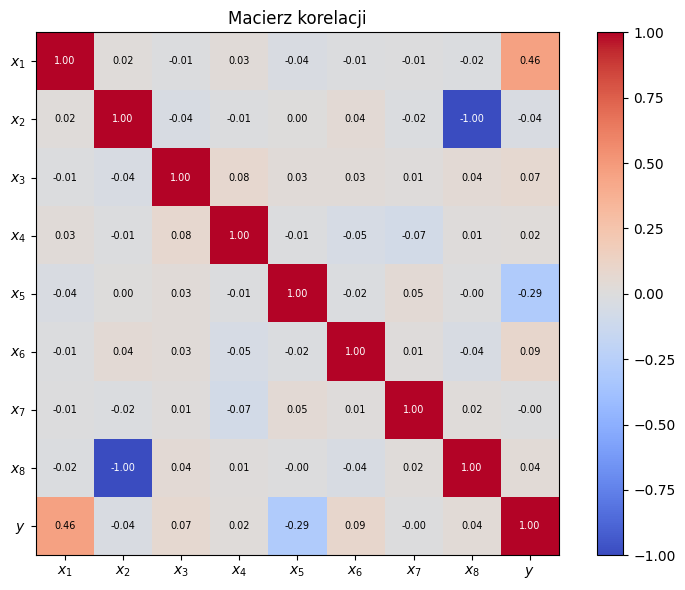

In [3]:
full_data = np.hstack([X_train_scaled, y_train.reshape(-1, 1)])
corr_matrix = np.corrcoef(full_data, rowvar=False)
labels = [f'$x_{i}$' for i in range(1, 9)] + ['$y$']

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_title('Macierz korelacji')
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr_matrix[i, j]) > 0.5 else 'black')
plt.tight_layout()
plt.savefig('images/correlation_matrix.png', dpi=150)
plt.show()

## Gradient Descent - pełny

Train MSE: 10602.6541
Test  MSE: 11436.5119


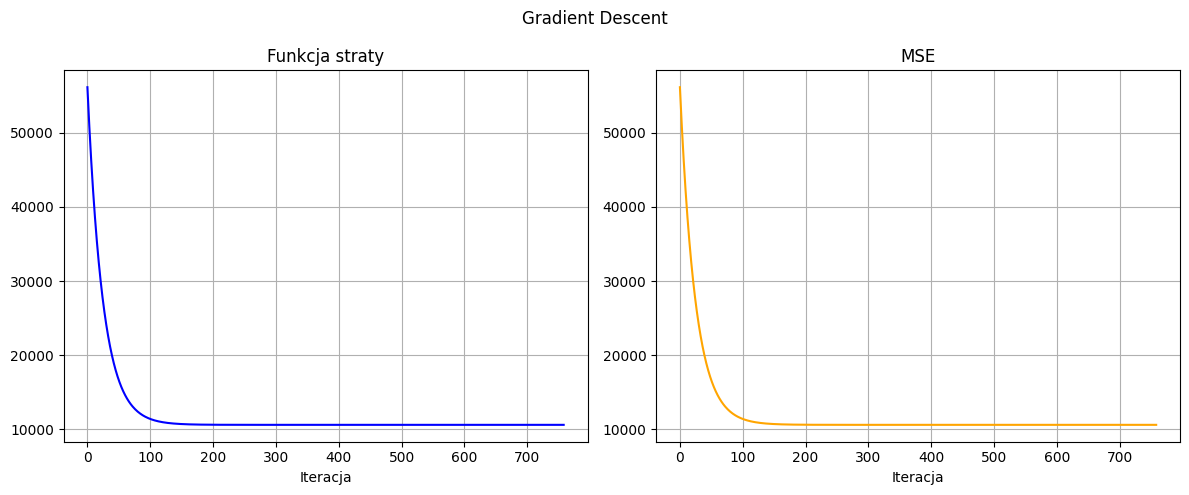

In [4]:
model_gd = LinearRegressionModel(Linear(), Quadratic())
model_gd.fit_gradient_descent(X_train_scaled, y_train, alpha=0.01, max_iter=1000)

print(f'Train MSE: {model_gd.mse(X_train_scaled, y_train):.4f}')
print(f'Test  MSE: {model_gd.mse(X_test_scaled, y_test):.4f}')

iterations = [h[0] for h in model_gd.history]
losses = [h[1] for h in model_gd.history]
mses = [h[2] for h in model_gd.history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(iterations, losses, color='blue')
ax1.set_title('Funkcja straty')
ax1.set_xlabel('Iteracja')
ax1.grid(True)
ax2.plot(iterations, mses, color='orange')
ax2.set_title('MSE')
ax2.set_xlabel('Iteracja')
ax2.grid(True)
fig.suptitle('Gradient Descent')
plt.tight_layout()
plt.savefig('images/gd_training.png', dpi=150)
plt.show()

## Mini-batch Gradient Descent

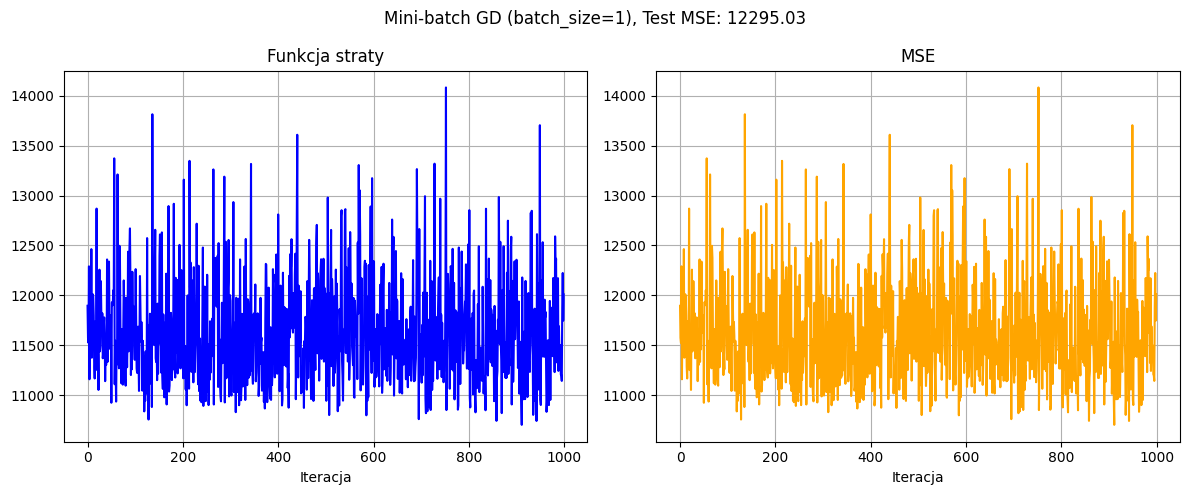

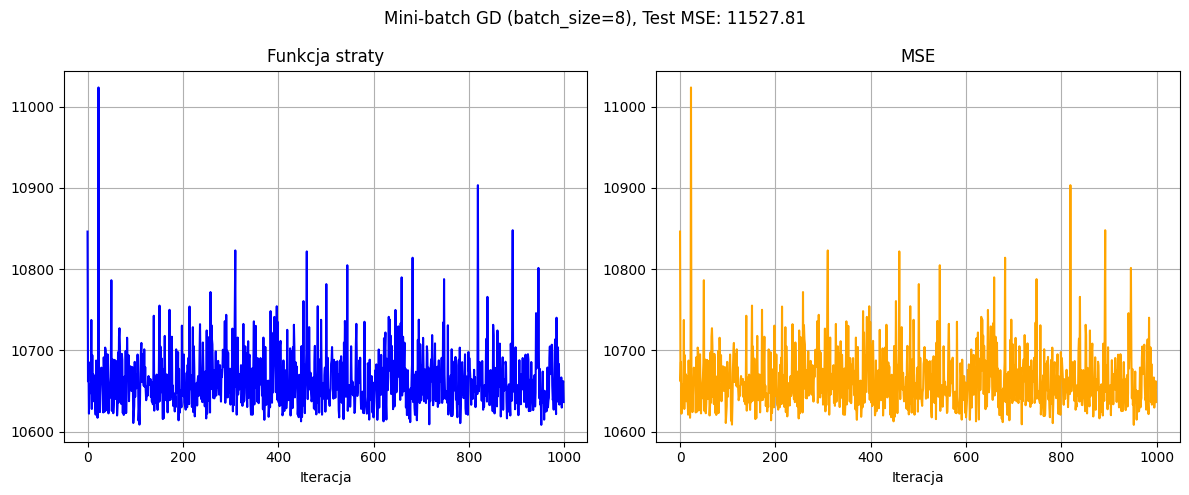

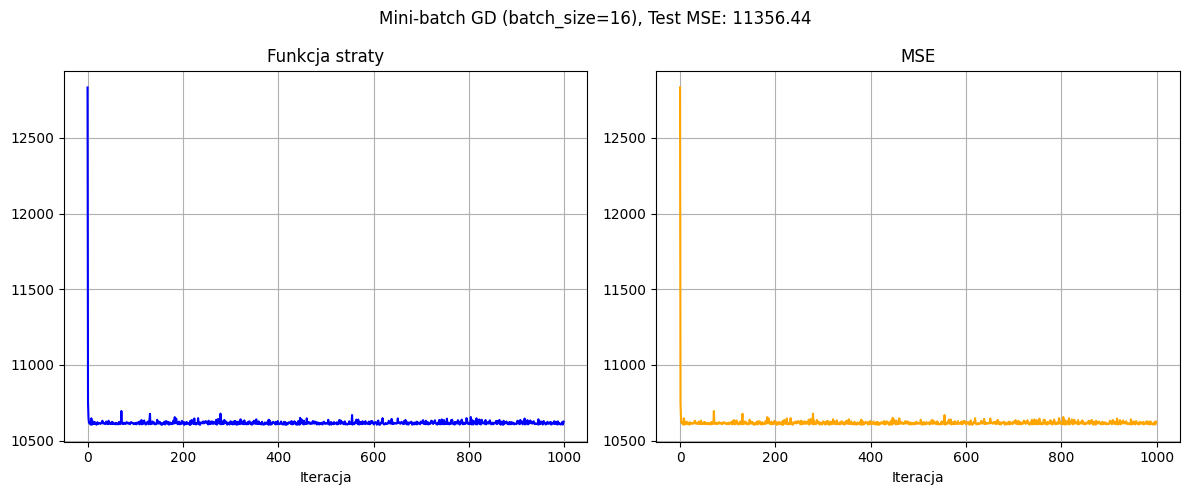

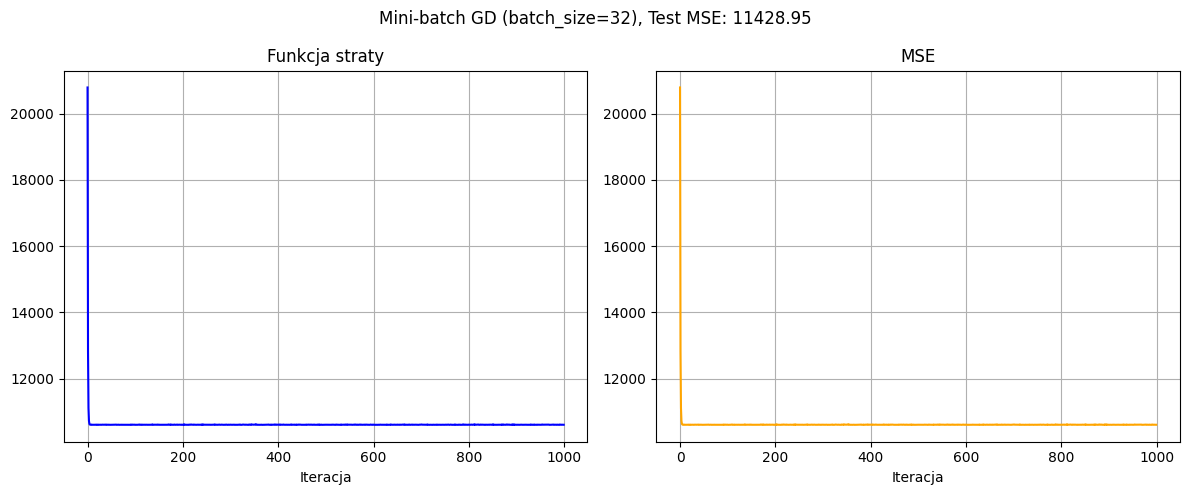

In [5]:
for batch_size in [1, 8, 16, 32]:
    model_mb = LinearRegressionModel(Linear(), Quadratic())
    model_mb.fit_minibatch(X_train_scaled, y_train, alpha=0.01, max_iter=1000, batch_size=batch_size)
    
    test_mse = model_mb.mse(X_test_scaled, y_test)
    iterations = [h[0] for h in model_mb.history]
    losses = [h[1] for h in model_mb.history]
    mses = [h[2] for h in model_mb.history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(iterations, losses, color='blue')
    ax1.set_title('Funkcja straty')
    ax1.set_xlabel('Iteracja')
    ax1.grid(True)
    ax2.plot(iterations, mses, color='orange')
    ax2.set_title('MSE')
    ax2.set_xlabel('Iteracja')
    ax2.grid(True)
    fig.suptitle(f'Mini-batch GD (batch_size={batch_size}), Test MSE: {test_mse:.2f}')
    plt.tight_layout()
    plt.savefig(f'images/minibatch_{batch_size}.png', dpi=150)
    plt.show()

## Regularyzacja L1

Best L1: 0.0001, MSE: 10221.1001


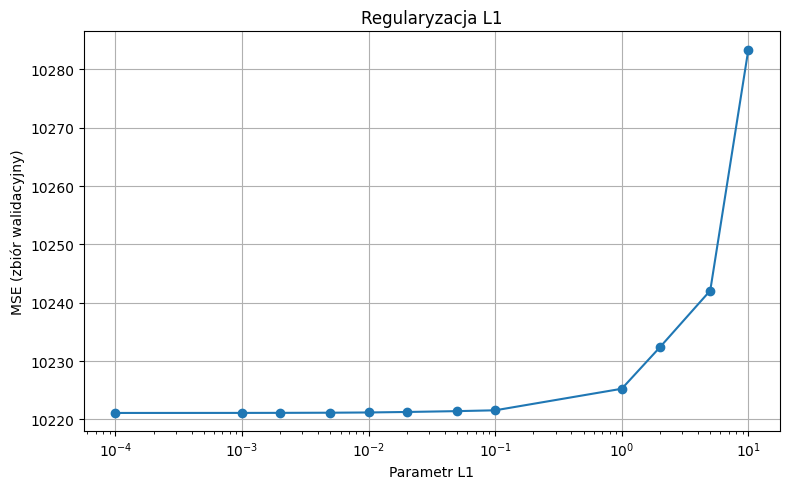

In [6]:
reg_params = [0.0001, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 1, 2, 5, 10]

l1_mse_values = []
for reg in reg_params:
    model_reg = LinearRegressionModel(Linear(), Quadratic())
    model_reg.fit_gradient_descent(X_train_scaled, y_train, alpha=0.01, max_iter=1000, l1=reg)
    l1_mse_values.append(model_reg.mse(X_valid_scaled, y_valid))

best_l1 = reg_params[np.argmin(l1_mse_values)]
print(f'Best L1: {best_l1}, MSE: {min(l1_mse_values):.4f}')

plt.figure(figsize=(8, 5))
plt.plot(reg_params, l1_mse_values, 'o-')
plt.xscale('log')
plt.xlabel('Parametr L1')
plt.ylabel('MSE (zbiór walidacyjny)')
plt.title('Regularyzacja L1')
plt.grid(True)
plt.tight_layout()
plt.savefig('images/l1_regularization.png', dpi=150)
plt.show()

## Regularyzacja L2

Best L2: 0.1, MSE: 10183.4773


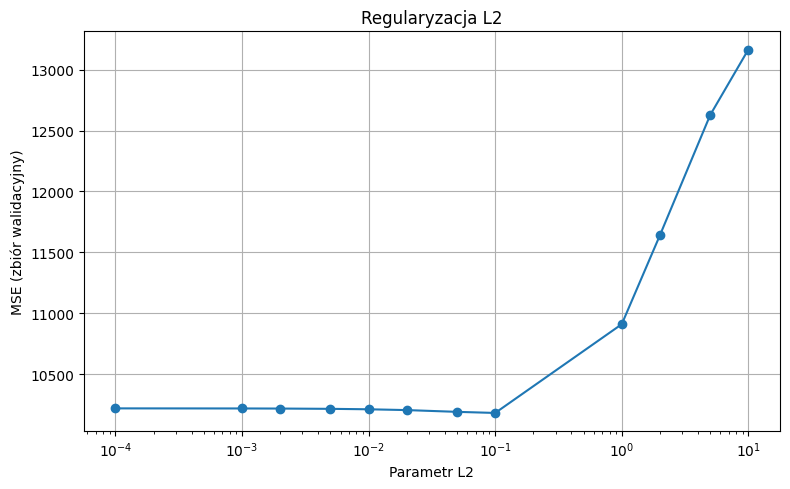

In [7]:
l2_mse_values = []
for reg in reg_params:
    model_reg = LinearRegressionModel(Linear(), Quadratic())
    model_reg.fit_gradient_descent(X_train_scaled, y_train, alpha=0.01, max_iter=1000, l2=reg)
    l2_mse_values.append(model_reg.mse(X_valid_scaled, y_valid))

best_l2 = reg_params[np.argmin(l2_mse_values)]
print(f'Best L2: {best_l2}, MSE: {min(l2_mse_values):.4f}')

plt.figure(figsize=(8, 5))
plt.plot(reg_params, l2_mse_values, 'o-')
plt.xscale('log')
plt.xlabel('Parametr L2')
plt.ylabel('MSE (zbiór walidacyjny)')
plt.title('Regularyzacja L2')
plt.grid(True)
plt.tight_layout()
plt.savefig('images/l2_regularization.png', dpi=150)
plt.show()

## Funkcje bazowe - wielomiany

Stopień 1: Valid MSE = 10221.10, Test MSE = 11436.51
Stopień 2: Valid MSE = 9990.22, Test MSE = 11161.01
Stopień 3: Valid MSE = 9825.96, Test MSE = 11165.60
Stopień 4: Valid MSE = 4799.84, Test MSE = 5157.89
Stopień 5: Valid MSE = 4678.08, Test MSE = 4942.57


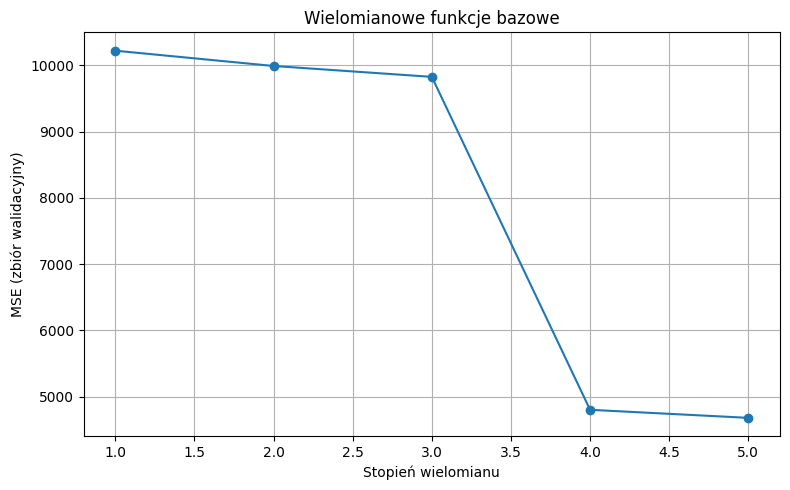

In [8]:
degrees = [1, 2, 3, 4, 5]
poly_mse = []
for d in degrees:
    m = LinearRegressionModel(Polynomial(d), Quadratic())
    m.fit_gradient_descent(X_train_scaled, y_train, alpha=0.01, max_iter=1000)
    mse_val = m.mse(X_valid_scaled, y_valid)
    mse_test = m.mse(X_test_scaled, y_test)
    poly_mse.append(mse_val)
    print(f'Stopień {d}: Valid MSE = {mse_val:.2f}, Test MSE = {mse_test:.2f}')

plt.figure(figsize=(8, 5))
plt.plot(degrees, poly_mse, 'o-')
plt.xlabel('Stopień wielomianu')
plt.ylabel('MSE (zbiór walidacyjny)')
plt.title('Wielomianowe funkcje bazowe')
plt.grid(True)
plt.tight_layout()
plt.savefig('images/polynomial_comparison.png', dpi=150)
plt.show()

## Funkcje bazowe - gaussowskie

Best sigma: 0.5, Valid MSE: 3438.98


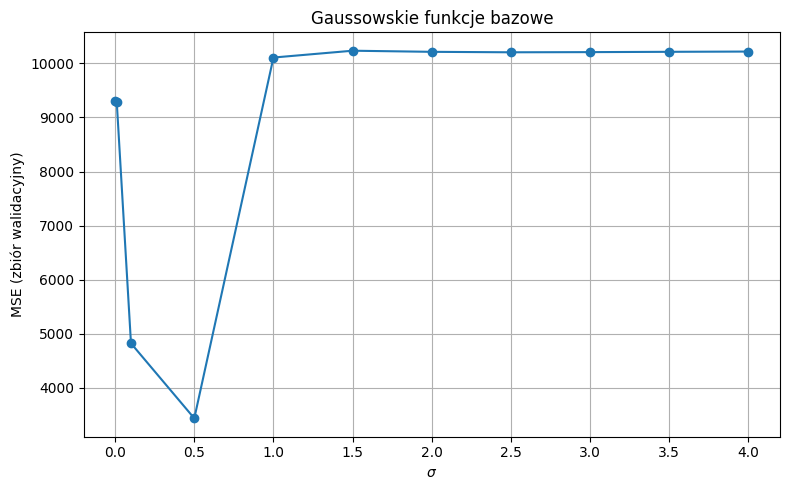

In [9]:
sigmas = [0.001, 0.01, 0.1, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]
gauss_mse = []
for s in sigmas:
    m = LinearRegressionModel(Combined([Linear(), Gaussian(s)]), Quadratic())
    m.fit_gradient_descent(X_train_scaled, y_train, alpha=0.01, max_iter=1000)
    gauss_mse.append(m.mse(X_valid_scaled, y_valid))

best_sigma = sigmas[np.argmin(gauss_mse)]
print(f'Best sigma: {best_sigma}, Valid MSE: {min(gauss_mse):.2f}')

plt.figure(figsize=(8, 5))
plt.plot(sigmas, gauss_mse, 'o-')
plt.xlabel('$\\sigma$')
plt.ylabel('MSE (zbiór walidacyjny)')
plt.title('Gaussowskie funkcje bazowe')
plt.grid(True)
plt.tight_layout()
plt.savefig('images/gaussian_comparison.png', dpi=150)
plt.show()

## Funkcje bazowe - Fourier

Best freq: 80, Valid MSE: 1647.52


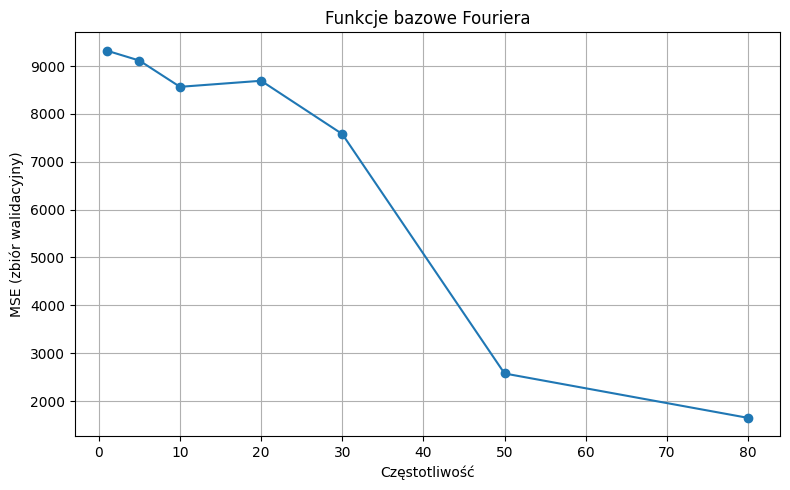

In [10]:
freqs = [1, 5, 10, 20, 30, 50, 80]
fourier_mse = []
for f in freqs:
    m = LinearRegressionModel(Combined([Linear(), Fourier(f)]), Quadratic())
    m.fit_gradient_descent(X_train_scaled, y_train, alpha=0.01, max_iter=1000)
    fourier_mse.append(m.mse(X_valid_scaled, y_valid))

best_freq = freqs[np.argmin(fourier_mse)]
print(f'Best freq: {best_freq}, Valid MSE: {min(fourier_mse):.2f}')

plt.figure(figsize=(8, 5))
plt.plot(freqs, fourier_mse, 'o-')
plt.xlabel('Częstotliwość')
plt.ylabel('MSE (zbiór walidacyjny)')
plt.title('Funkcje bazowe Fouriera')
plt.grid(True)
plt.tight_layout()
plt.savefig('images/fourier_comparison.png', dpi=150)
plt.show()

## Funkcje bazowe - sigmoid

Best sigma: 0.1, Valid MSE: 9414.64


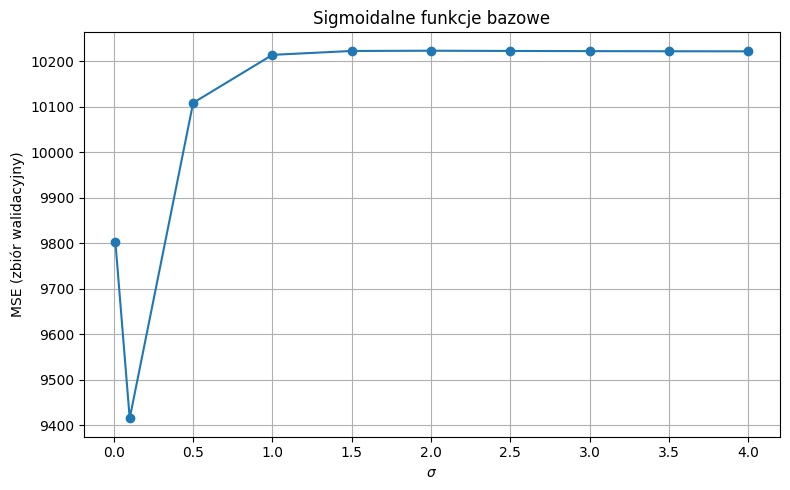

In [11]:
sigmas_sig = [0.01, 0.1, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]
sig_mse = []
for s in sigmas_sig:
    m = LinearRegressionModel(Combined([Linear(), Sigmoid(s)]), Quadratic())
    m.fit_gradient_descent(X_train_scaled, y_train, alpha=0.01, max_iter=1000)
    sig_mse.append(m.mse(X_valid_scaled, y_valid))

best_sig = sigmas_sig[np.argmin(sig_mse)]
print(f'Best sigma: {best_sig}, Valid MSE: {min(sig_mse):.2f}')

plt.figure(figsize=(8, 5))
plt.plot(sigmas_sig, sig_mse, 'o-')
plt.xlabel('$\\sigma$')
plt.ylabel('MSE (zbiór walidacyjny)')
plt.title('Sigmoidalne funkcje bazowe')
plt.grid(True)
plt.tight_layout()
plt.savefig('images/sigmoid_comparison.png', dpi=150)
plt.show()

## Porównanie funkcji bazowych - Test MSE

In [12]:
models = {
    'Liniowy': LinearRegressionModel(Linear(), Quadratic()),
    'Wielomian (st. 5)': LinearRegressionModel(Polynomial(5), Quadratic()),
    'Gaussian': LinearRegressionModel(Combined([Linear(), Gaussian(best_sigma)]), Quadratic()),
    'Fourier': LinearRegressionModel(Combined([Linear(), Fourier(best_freq)]), Quadratic()),
    'Sigmoid': LinearRegressionModel(Combined([Linear(), Sigmoid(best_sig)]), Quadratic()),
}

print(f'{"Model":<20} {"Train MSE":>12} {"Test MSE":>12}')
print('-' * 46)
for name, model in models.items():
    model.fit_gradient_descent(X_train_scaled, y_train, alpha=0.01, max_iter=1000)
    tr = model.mse(X_train_scaled, y_train)
    te = model.mse(X_test_scaled, y_test)
    print(f'{name:<20} {tr:>12.2f} {te:>12.2f}')

Model                   Train MSE     Test MSE
----------------------------------------------
Liniowy                  10602.65     11436.51
Wielomian (st. 5)         4450.38      4942.57
Gaussian                  3484.13      4042.12
Fourier                   1298.84      1621.60
Sigmoid                   9531.40     10389.92


## Krzywe uczenia - model liniowy

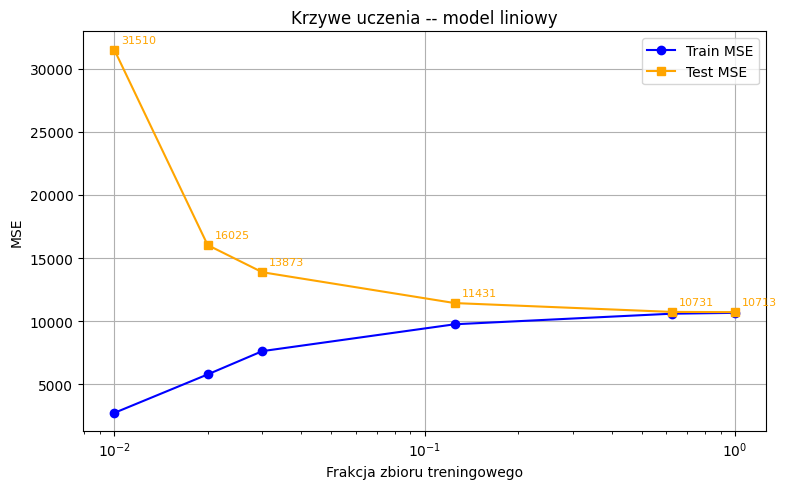

   Frakcja    Train MSE     Test MSE
     0.010      2730.76     31509.82
     0.020      5781.43     16024.56
     0.030      7625.74     13873.49
     0.125      9752.59     11431.15
     0.625     10590.31     10731.49
     1.000     10657.23     10712.83


In [13]:
fractions = [0.01, 0.02, 0.03, 0.125, 0.625, 1]

model_lin = LinearRegressionModel(Linear(), Quadratic())
avg_train, avg_test = compute_learning_curves(model_lin, fractions, n_runs=10, file_path=data_file)

plt.figure(figsize=(8, 5))
plt.semilogx(fractions, avg_train, 'o-', label='Train MSE', color='blue')
plt.semilogx(fractions, avg_test, 's-', label='Test MSE', color='orange')
for f, tr, te in zip(fractions, avg_train, avg_test):
    plt.annotate(f'{te:.0f}', (f, te), textcoords='offset points', xytext=(5, 5), fontsize=8, color='orange')
plt.xlabel('Frakcja zbioru treningowego')
plt.ylabel('MSE')
plt.title('Krzywe uczenia -- model liniowy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('images/learning_curves_linear.png', dpi=150)
plt.show()

# Tabelka
print(f'{"Frakcja":>10} {"Train MSE":>12} {"Test MSE":>12}')
for f, tr, te in zip(fractions, avg_train, avg_test):
    print(f'{f:>10.3f} {tr:>12.2f} {te:>12.2f}')

## Krzywe uczenia - wielomian stopnia 4

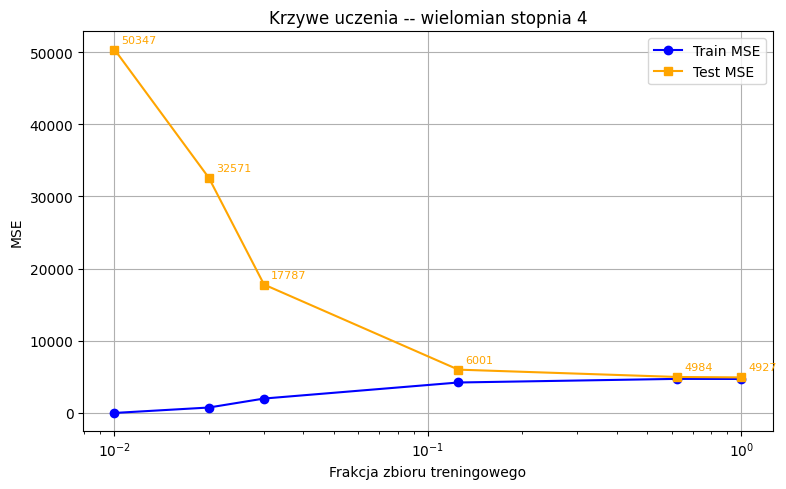

   Frakcja    Train MSE     Test MSE
     0.010         1.61     50346.96
     0.020       753.83     32570.90
     0.030      1998.12     17787.23
     0.125      4219.74      6001.16
     0.625      4722.90      4984.21
     1.000      4708.32      4927.22


In [14]:
model_p4 = LinearRegressionModel(Polynomial(4), Quadratic())
avg_train_p, avg_test_p = compute_learning_curves(model_p4, fractions, n_runs=10, file_path=data_file)

plt.figure(figsize=(8, 5))
plt.semilogx(fractions, avg_train_p, 'o-', label='Train MSE', color='blue')
plt.semilogx(fractions, avg_test_p, 's-', label='Test MSE', color='orange')
for f, tr, te in zip(fractions, avg_train_p, avg_test_p):
    plt.annotate(f'{te:.0f}', (f, te), textcoords='offset points', xytext=(5, 5), fontsize=8, color='orange')
plt.xlabel('Frakcja zbioru treningowego')
plt.ylabel('MSE')
plt.title('Krzywe uczenia -- wielomian stopnia 4')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('images/learning_curves_poly4.png', dpi=150)
plt.show()

# Tabelka
print(f'{"Frakcja":>10} {"Train MSE":>12} {"Test MSE":>12}')
for f, tr, te in zip(fractions, avg_train_p, avg_test_p):
    print(f'{f:>10.3f} {tr:>12.2f} {te:>12.2f}')